# Linear Regression

## Goal

In this notebook, we train our first machine learning model.

Steps:

- Load the prepared training and testing datasets
- Train a Linear Regression model
- Predict laptop prices
- Evaluate the model

In [8]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [9]:
from pathlib import Path

import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Load Training and Testing Data

Load the processed datasets created in the previous notebook.

In [10]:
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

In [11]:
X_train = pd.read_csv(DATA_PROCESSED / "X_train.csv")

X_test = pd.read_csv(DATA_PROCESSED / "X_test.csv")

y_train = pd.read_csv(DATA_PROCESSED / "y_train.csv")

y_test = pd.read_csv(DATA_PROCESSED / "y_test.csv")

In [12]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(1020, 71)
(255, 71)
(1020, 1)
(255, 1)


In [13]:
y_train = y_train.squeeze()

y_test = y_test.squeeze()

In [14]:
type(y_train)

pandas.Series

## Train Linear Regression Model

We train our first machine learning model using the training dataset.

The model learns the relationship between laptop specifications and price.

In [15]:
# Model making
model = LinearRegression()

In [ ]:
# Model training
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](71,)","[ -53.82, 95.55, 44.04,..., 548.53,-266.46, 18.82]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](71,)","['inches','cpu_frequency','ram',...,'gpu_family_Quadro', 'gpu_family_Radeon','gpu_family_UHD Graphics']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,241.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,71
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(62)


In [17]:
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](71,)","[ -53.82, 95.55, 44.04,..., 548.53,-266.46, 18.82]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](71,)","['inches','cpu_frequency','ram',...,'gpu_family_Quadro', 'gpu_family_Radeon','gpu_family_UHD Graphics']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,241.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,71
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(62)


## Predict Laptop Prices

Use the trained model to predict prices for the testing dataset.

In [18]:
y_pred = model.predict(X_test)

In [19]:
y_pred[:10]

array([ 544.59266303,  736.82979204, 1483.36802386,  839.29198418,
       1415.79841735,  887.96194393, 1245.94544193,  230.55575756,
       1945.60956779,  690.87723736])

In [20]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,650.00,544.592663
1,716.00,736.829792
2,1584.00,1483.368024
3,1020.00,839.291984
4,1749.00,1415.798417
5,557.37,887.961944
6,999.00,1245.945442
7,330.00,230.555758
8,2267.86,1945.609568
9,682.00,690.877237


## Evaluate the Model

After training the model, we evaluate its performance using regression metrics.

In [21]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

In [22]:
print(f"MAE  : {mae:.2f}")

print(f"MSE  : {mse:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R²   : {r2:.4f}")

MAE  : 241.02
MSE  : 106454.26
RMSE : 326.27
R²   : 0.7855


## Actual vs Predicted Prices

Compare the actual laptop prices with the prices predicted by the Linear Regression model.

In [23]:
import matplotlib.pyplot as plt

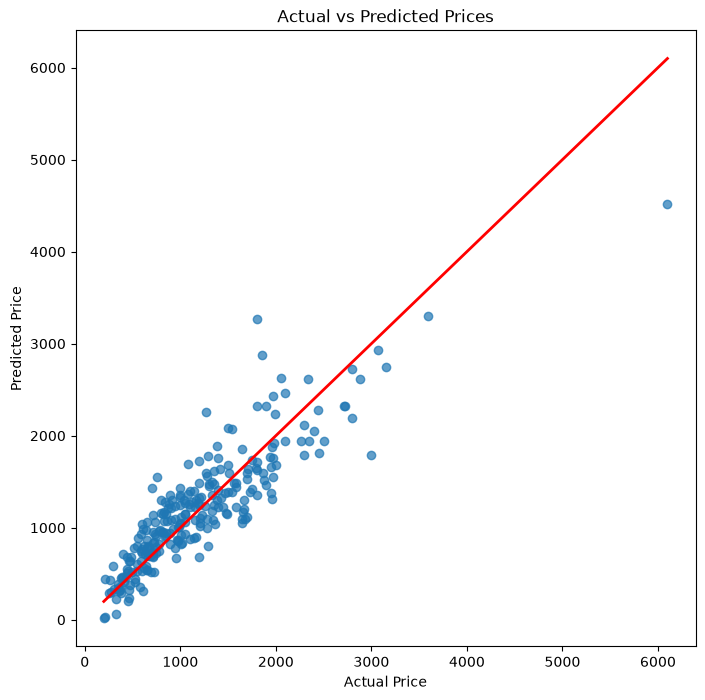

In [25]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

## Residual Analysis

Analyze prediction errors.

In [26]:
residuals = y_test - y_pred

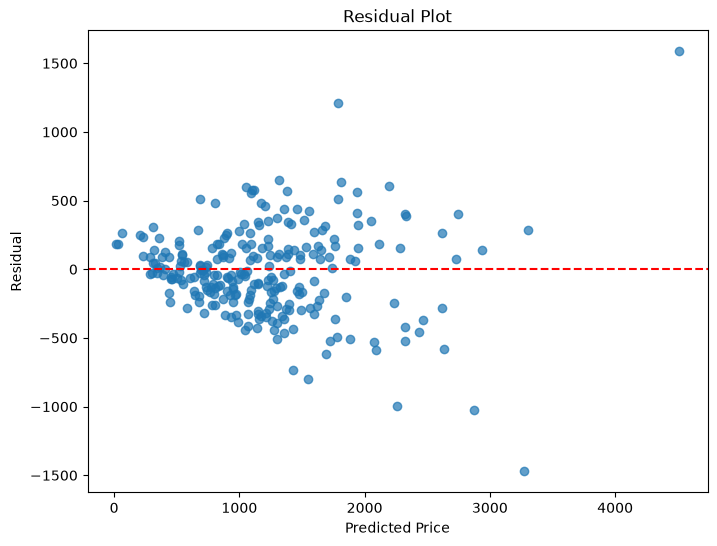

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

# Model Interpretation

In this section we inspect the coefficients learned by the Linear Regression model.

In [28]:
coefficients = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Coefficient": model.coef_
    }
)

coefficients.head()

,Feature,Coefficient
0,inches,-53.819166
1,cpu_frequency,95.554555
2,ram,44.044992
3,weight,195.938443
4,ssd,0.721575


In [29]:
coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients.head(20)

,Feature,Coefficient
27,company_Razer,995.879721
68,gpu_family_Quadro,548.534418
22,company_LG,546.012478
54,cpu_family_AMD,412.374658
52,operating_system_Windows 7,364.888236
39,cpu_company_Intel,317.163532
60,cpu_family_Other,307.759831
62,gpu_family_FirePro,256.692039
3,weight,195.938443
36,type_name_Ultrabook,177.811970


In [30]:
coefficients.tail(20)

,Feature,Coefficient
43,gpu_company_Intel,-123.910997
45,operating_system_Android,-131.782575
26,company_Microsoft,-142.731449
57,cpu_family_Core i3,-153.132273
49,operating_system_No OS,-163.528529
35,type_name_Notebook,-164.699350
13,company_Acer,-168.496661
61,cpu_family_Pentium,-182.991756
30,company_Vero,-185.649887
56,cpu_family_Celeron,-186.457858


In [31]:
top_positive = coefficients.head(10)

top_positive

,Feature,Coefficient
27,company_Razer,995.879721
68,gpu_family_Quadro,548.534418
22,company_LG,546.012478
54,cpu_family_AMD,412.374658
52,operating_system_Windows 7,364.888236
39,cpu_company_Intel,317.163532
60,cpu_family_Other,307.759831
62,gpu_family_FirePro,256.692039
3,weight,195.938443
36,type_name_Ultrabook,177.811970


In [32]:
top_negative = coefficients.tail(10)

top_negative

,Feature,Coefficient
63,gpu_family_GTX,-203.252526
38,cpu_company_AMD,-203.572065
18,company_Fujitsu,-250.622049
55,cpu_family_Atom,-256.365619
48,operating_system_Mac OS X,-260.847399
69,gpu_family_Radeon,-266.461844
66,gpu_family_MX,-290.002832
16,company_Chuwi,-316.212026
67,gpu_family_Other,-316.730643
21,company_Huawei,-377.249046


In [34]:
import matplotlib.pyplot as plt

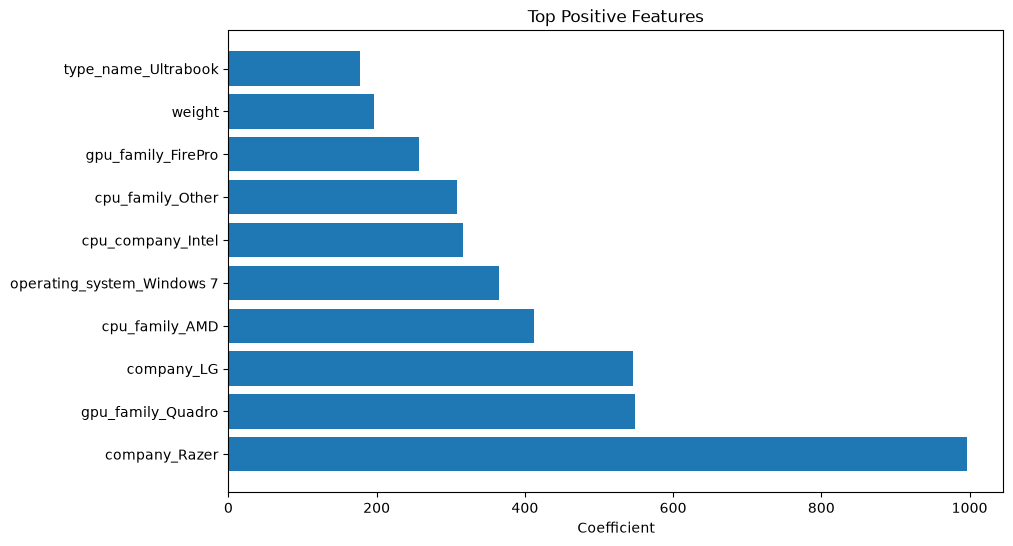

In [35]:
plt.figure(figsize=(10,6))

plt.barh(
    top_positive["Feature"],
    top_positive["Coefficient"]
)

plt.title("Top Positive Features")

plt.xlabel("Coefficient")

plt.show()

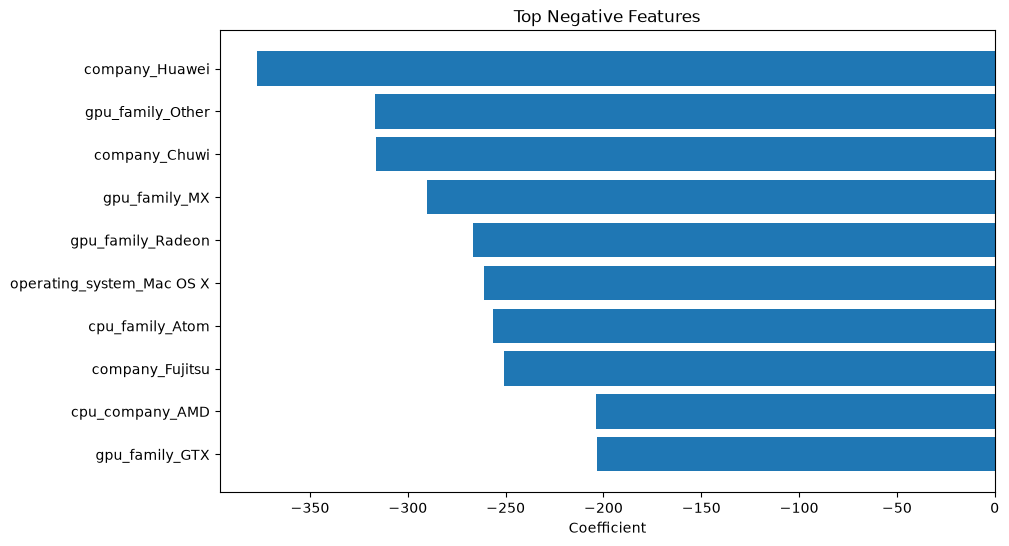

In [36]:
plt.figure(figsize=(10,6))

plt.barh(
    top_negative["Feature"],
    top_negative["Coefficient"]
)

plt.title("Top Negative Features")

plt.xlabel("Coefficient")

plt.show()

## Summary

In this notebook:

- Trained a Linear Regression model
- Evaluated the model
- Visualized predictions
- Inspected residuals
- Interpreted model coefficients

The model achieved a good baseline performance and is ready to be compared with more advanced algorithms.